## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

## Lecture des données

In [2]:
dtypes = {
    "perf_id": "int32",
    "perf_temps": "float32",
    "perf_distance": "int16",
    "perf_bassin": "int8",
    "competition_ville": "category",
    "competition_pays": "category",
    "nageur_id": "int32",
    "nageur_sexe": "category",
    "nageur_pays": "category",
    "nageur_age_mois": "int16",
    "mois_saison": "int8",
    "perf_nage": "category"
}

parse_dates = ["perf_date", "nageur_date_naissance"]

data = pd.read_csv(
    "../data/performances.csv",
    dtype=dtypes,
    parse_dates=parse_dates
)

print(data.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15196047 entries, 0 to 15196046
Data columns (total 14 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   perf_id                int32         
 1   perf_date              datetime64[ns]
 2   perf_temps             float32       
 3   perf_nage              category      
 4   perf_distance          int16         
 5   perf_bassin            int8          
 6   competition_ville      category      
 7   competition_pays       category      
 8   nageur_id              int32         
 9   nageur_sexe            category      
 10  nageur_date_naissance  object        
 11  nageur_pays            category      
 12  nageur_age_mois        int16         
 13  mois_saison            int8          
dtypes: category(5), datetime64[ns](1), float32(1), int16(2), int32(2), int8(2), object(1)
memory usage: 1.3 GB
None


Nous supprimons les valeurs invalides du jeu de données.

In [3]:
data = data.dropna(how='any',axis=0)
data.describe()

,perf_id,perf_date,perf_temps,perf_distance,perf_bassin,nageur_id,nageur_age_mois,mois_saison
count,1.519605e+07,15196047,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07
mean,1.298771e+07,2016-10-02 08:20:25.794791168,1.748004e+00,1.398700e+02,3.331302e+01,1.593994e+06,1.938763e+02,5.521579e+00
min,1.000000e+00,1996-04-04 00:00:00,1.085000e-01,2.500000e+01,2.500000e+01,-1.058890e+05,-2.612100e+04,0.000000e+00
25%,8.078232e+06,2012-12-02 00:00:00,4.155000e-01,5.000000e+01,2.500000e+01,9.889990e+05,1.460000e+02,3.000000e+00
50%,1.342845e+07,2016-11-20 00:00:00,1.142200e+00,1.000000e+02,2.500000e+01,1.480898e+06,1.690000e+02,6.000000e+00
75%,1.846193e+07,2021-10-10 00:00:00,2.211300e+00,2.000000e+02,5.000000e+01,2.099575e+06,1.980000e+02,8.000000e+00
max,2.322727e+07,2025-06-19 00:00:00,6.140700e+02,3.000000e+03,5.000000e+01,4.404826e+06,1.211000e+03,1.100000e+01
std,6.423676e+06,NaN,2.384063e+00,1.680907e+02,1.177791e+01,9.359901e+05,1.029630e+02,2.786871e+00


Ici, nous observons certaines anomalies, comme le fait que la variable `nageur_age_mois` ait une valeur minimale inférieure à 0.

In [4]:
data = data[data['nageur_age_mois'] > 0]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15196044 entries, 0 to 15196046
Data columns (total 14 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   perf_id                int32         
 1   perf_date              datetime64[ns]
 2   perf_temps             float32       
 3   perf_nage              category      
 4   perf_distance          int16         
 5   perf_bassin            int8          
 6   competition_ville      category      
 7   competition_pays       category      
 8   nageur_id              int32         
 9   nageur_sexe            category      
 10  nageur_date_naissance  object        
 11  nageur_pays            category      
 12  nageur_age_mois        int16         
 13  mois_saison            int8          
dtypes: category(5), datetime64[ns](1), float32(1), int16(2), int32(2), int8(2), object(1)
memory usage: 710.2+ MB


## Data Analysis

In [5]:
data[['nageur_age_mois']].describe()

,nageur_age_mois
count,1.519604e+07
mean,1.938815e+02
std,1.022970e+02
min,8.000000e+00
25%,1.460000e+02
50%,1.690000e+02
75%,1.980000e+02
max,1.211000e+03


L'âge moyen d'un nageur ici est de 193 mois (16 ans). La médiane est de 169 (14 ans), tandis que la valeur maximale est de 1211 mois (100 ans !!) et la valeur minimale semble être une anomalie avec seulement 8 mois. Après quelques recherches, il semble qu'en France il n'est pas possible de nager en club avant 4 ans (48 mois), donc nous filtrons ces cas.

In [6]:
data = data[data['nageur_age_mois'] > 48]
data[['nageur_age_mois']].describe()

,nageur_age_mois
count,1.519604e+07
mean,1.938815e+02
std,1.022970e+02
min,4.900000e+01
25%,1.460000e+02
50%,1.690000e+02
75%,1.980000e+02
max,1.211000e+03


Nous avons maintenant une valeur minimale de 49 mois, ce qui semble légitime.

<Axes: ylabel='Frequency'>

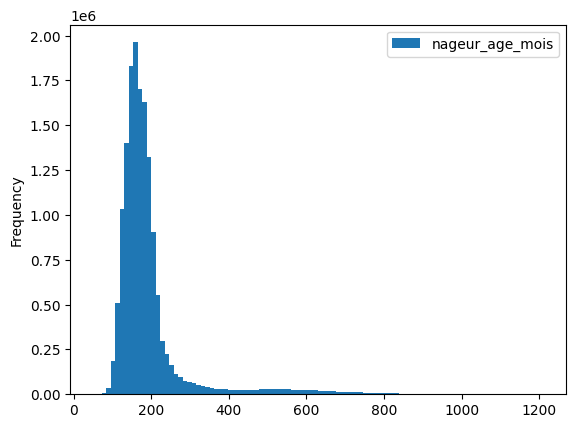

In [7]:
data[['nageur_age_mois']].plot.hist(bins=100)

Nous constatons que la majorité des compétiteurs ont entre 150 et 300 mois (soit entre 12 et 25 ans). Le reste est assez bien réparti entre 400 et 800 mois (33 à 66 ans). La population des compétiteurs en natation est donc surreprésentée par les jeunes.

<Axes: xlabel='perf_distance'>

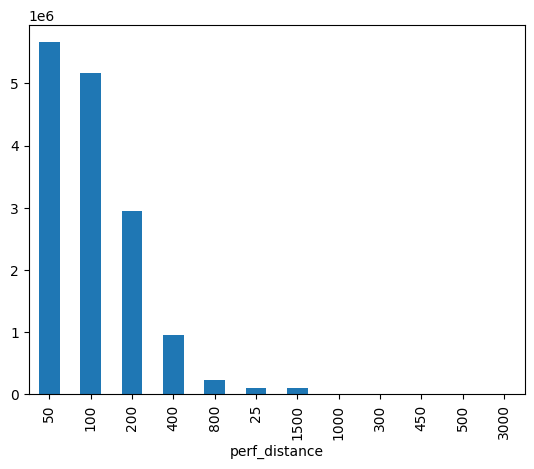

In [8]:
data['perf_distance'].value_counts().plot.bar()

Nous constatons ici que les distances les plus représentées en compétition sont 50, 100 et 200 mètres. Cela reflète la popularité des épreuves de sprint et de demi-fond en natation, qui attirent le plus grand nombre de participants. Les autres distances, bien que présentes, sont moins courantes et concernent souvent des nageurs spécialisés ou des compétitions spécifiques.

<Axes: xlabel='perf_nage'>

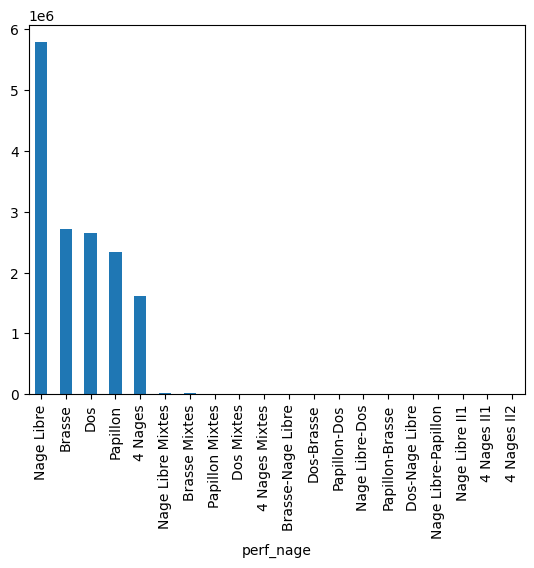

In [9]:
data['perf_nage'].value_counts().plot.bar()

La catégorie Nage libre est de loin la plus représentée en compétition, avec la Brasse, le Dos, le Papillon et les 4 Nages également bien présents. Toutes les autres catégories sont des variantes ou des versions mixtes de ces grandes catégories.

<Axes: xlabel='perf_bassin'>

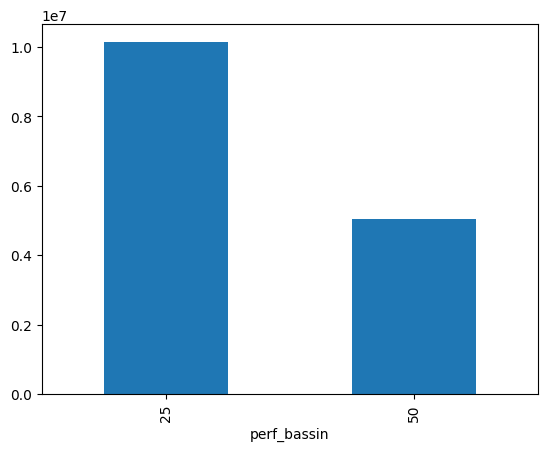

In [10]:
data['perf_bassin'].value_counts().plot.bar()

Nous constatons ici que la majorité des compétitions se déroulent dans des piscines semi-olympiques de 25 mètres, soit environ deux fois plus que dans des piscines olympiques de 50 mètres. Cela s’explique notamment par le fait que les piscines de 25 mètres sont plus répandues en France, facilitant l’organisation de compétitions locales et régionales. Les piscines olympiques, plus rares et coûteuses, sont généralement réservées aux grandes compétitions nationales ou internationales.

<Axes: xlabel='mois_saison'>

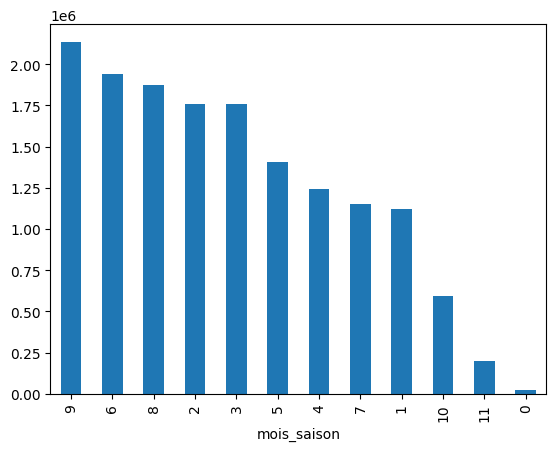

In [11]:
data['mois_saison'].value_counts().plot.bar()

Les compétitions de natation ne sont pas réparties uniformément tout au long de l'année. Elles atteignent un pic à certains mois, probablement en raison des calendriers scolaires, de la météo ou des programmes des compétitions nationales.

<Axes: xlabel='nageur_sexe'>

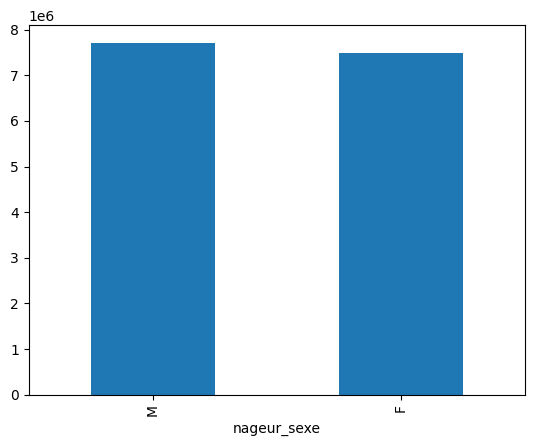

In [12]:
data['nageur_sexe'].value_counts().plot.bar()

Nous constatons ici que la participation aux compétitions de natation est répartie de manière égale entre les hommes et les femmes. Cela reflète une parité dans l'accès et l'intérêt pour la pratique de la natation en compétition, sans déséquilibre notable entre les deux sexes.

## Nettoyage et transformations des données

Nous allons retirer les colonnes inutiles à notre tâche d'apprentissage, puis transformer celles qui ont besoin de l'être.

In [13]:
data.drop(columns=['competition_ville', 'competition_pays', 'nageur_date_naissance', 'nageur_pays'], inplace=True)

In [14]:
data.head()

,perf_id,perf_date,perf_temps,perf_nage,perf_distance,perf_bassin,nageur_id,nageur_sexe,nageur_age_mois,mois_saison
0,3,1996-04-04,0.2663,Nage Libre,50,50,326914,F,244,7
1,185,1996-04-04,4.3242,Nage Libre,400,50,30347,F,219,7
2,186,1996-04-04,4.3277,Nage Libre,400,50,132447,F,240,7
3,189,1996-04-04,4.3465,Nage Libre,400,50,144752,F,168,7
4,193,1996-04-04,4.3657,Nage Libre,400,50,89589,F,192,7


On va maintenant visualiser le nombre de performance par nageur

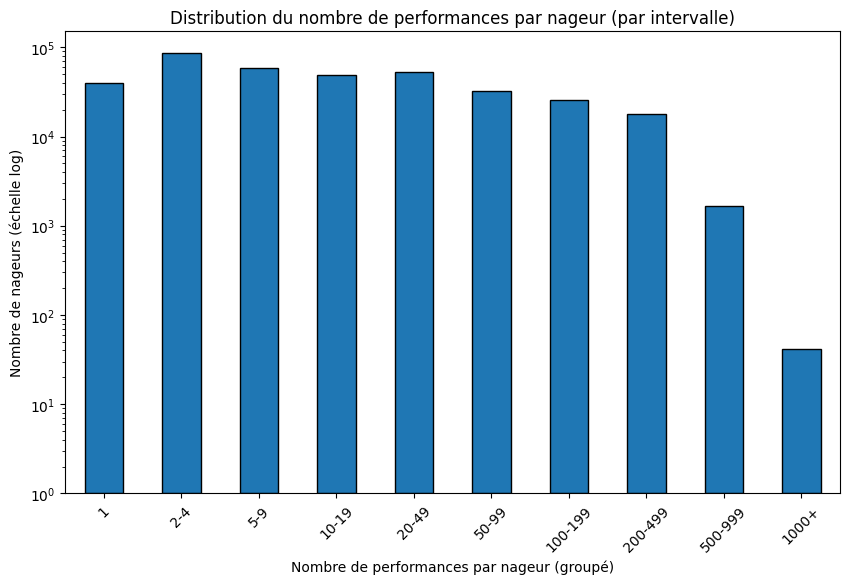

In [15]:
counts = data.groupby('nageur_id').size()
bins = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, counts.max()+1]
labels = ["1", "2-4", "5-9", "10-19", "20-49", "50-99", "100-199", "200-499", "500-999", "1000+"]

intervals = pd.cut(counts, bins=bins, labels=labels, right=False)
interval_counts = intervals.value_counts().sort_index()

plt.figure(figsize=(10,6))
interval_counts.plot(kind='bar', log=True, edgecolor='black')
plt.xlabel('Nombre de performances par nageur (groupé)')
plt.xticks(rotation=45)
plt.ylabel('Nombre de nageurs (échelle log)')
plt.title('Distribution du nombre de performances par nageur (par intervalle)')
plt.show()

On remarque que beaucoup de nageur effectue moins de 10 compétitions. Il est préférable de retirer ces performances de nos données, car comme nous voulons faire de la prédictions il nous faut des historiques un minimum fourni.

In [16]:
data = data.merge(counts.rename('performance_count'), left_on='nageur_id', right_index=True)
data = data[data['performance_count'] >= 10]
data.drop(columns=['performance_count'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14525094 entries, 2 to 15196046
Data columns (total 10 columns):
 #   Column           Dtype         
---  ------           -----         
 0   perf_id          int32         
 1   perf_date        datetime64[ns]
 2   perf_temps       float32       
 3   perf_nage        category      
 4   perf_distance    int16         
 5   perf_bassin      int8          
 6   nageur_id        int32         
 7   nageur_sexe      category      
 8   nageur_age_mois  int16         
 9   mois_saison      int8          
dtypes: category(2), datetime64[ns](1), float32(1), int16(2), int32(2), int8(2)
memory usage: 498.7 MB


Nous allons ignorer tous les types de nages trop peu représentés, puis les supprimer des données.

<Axes: xlabel='perf_nage'>

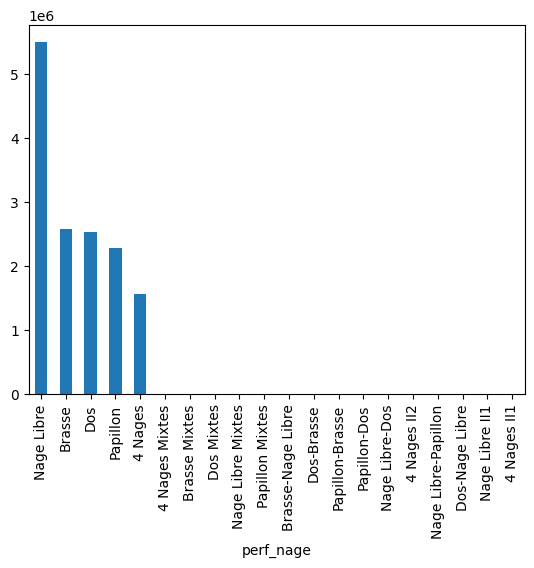

In [17]:
nage_counts = data['perf_nage'].value_counts()
valid_nages = nage_counts[nage_counts >= 100000].index
data = data[data['perf_nage'].isin(valid_nages)]
data['perf_nage'].value_counts().plot.bar()

On va maintenant transformer les labels de nage en donnée qu'on peut utiliser pour l'apprentissage (label numérique).

In [18]:
le = LabelEncoder()
data['perf_nage_encoded'] = le.fit_transform(data['perf_nage'])
data[['perf_nage', 'perf_nage_encoded']].drop_duplicates().sort_values('perf_nage_encoded')
data.drop(columns=['perf_nage'], inplace=True)
data.head()

,perf_id,perf_date,perf_temps,perf_distance,perf_bassin,nageur_id,nageur_sexe,nageur_age_mois,mois_saison,perf_nage_encoded
2,186,1996-04-04,4.3277,400,50,132447,F,240,7,3
3,189,1996-04-04,4.3465,400,50,144752,F,168,7,3
4,193,1996-04-04,4.3657,400,50,89589,F,192,7,3
5,204,1996-04-04,4.4322,400,50,277266,F,202,7,3
6,293,1996-04-04,2.1896,200,50,37047,F,250,7,2


On fait la meme chose pour `nageur_sexe`

In [19]:
le_sexe = LabelEncoder()
data['nageur_sexe_encoded'] = le_sexe.fit_transform(data['nageur_sexe'])
data[['nageur_sexe', 'nageur_sexe_encoded']].drop_duplicates().sort_values('nageur_sexe_encoded')
data.drop(columns=['nageur_sexe'], inplace=True)
data.head()

,perf_id,perf_date,perf_temps,perf_distance,perf_bassin,nageur_id,nageur_age_mois,mois_saison,perf_nage_encoded,nageur_sexe_encoded
2,186,1996-04-04,4.3277,400,50,132447,240,7,3,0
3,189,1996-04-04,4.3465,400,50,144752,168,7,3,0
4,193,1996-04-04,4.3657,400,50,89589,192,7,3,0
5,204,1996-04-04,4.4322,400,50,277266,202,7,3,0
6,293,1996-04-04,2.1896,200,50,37047,250,7,2,0


Maintenant, on a besoin de mettre à l'échelle l'âge en mois des nageurs pour faciliter l'apprentissage.

In [20]:
scaler = StandardScaler()
data['nageur_age_mois_scaled'] = scaler.fit_transform(data[['nageur_age_mois']])
data.drop(columns=['nageur_age_mois'], inplace=True)
data.head()

,perf_id,perf_date,perf_temps,perf_distance,perf_bassin,nageur_id,mois_saison,perf_nage_encoded,nageur_sexe_encoded,nageur_age_mois_scaled
2,186,1996-04-04,4.3277,400,50,132447,7,3,0,0.497070
3,189,1996-04-04,4.3465,400,50,144752,7,3,0,-0.241780
4,193,1996-04-04,4.3657,400,50,89589,7,3,0,0.004504
5,204,1996-04-04,4.4322,400,50,277266,7,3,0,0.107122
6,293,1996-04-04,2.1896,200,50,37047,7,2,0,0.599688


On encode le reste des paramètres

In [21]:
data['perf_distance'] = data['perf_distance'].astype(int)
data['perf_bassin'] = data['perf_bassin'].astype(int)

le_distance = LabelEncoder()
le_bassin = LabelEncoder()

data['perf_distance_encoded'] = le_distance.fit_transform(data['perf_distance'])
data['perf_bassin_encoded'] = le_bassin.fit_transform(data['perf_bassin'])
data.drop(columns=['perf_distance', 'perf_bassin'], inplace=True)

data = data.sort_values(['nageur_id', 'perf_date'])
data.head()

,perf_id,perf_date,perf_temps,nageur_id,mois_saison,perf_nage_encoded,nageur_sexe_encoded,nageur_age_mois_scaled,perf_distance_encoded,perf_bassin_encoded
12303518,23151598,2025-06-07,1.1668,-105487,9,3,1,-0.662513,2,0
12781927,23152048,2025-06-07,0.4759,-105487,9,4,1,-0.662513,1,0
14227860,23151806,2025-06-07,0.4279,-105487,9,4,1,-0.662513,1,0
14708430,23151626,2025-06-07,2.5836,-105487,9,3,1,-0.662513,3,0
15187740,23151856,2025-06-07,1.3617,-105487,9,0,1,-0.662513,2,0


On convertit mois_saison de façon cyclique pour que le modèle futur puisse comprendre que janvier (initialement 0) et décembre (initialement 11) sont des mois proches.

In [22]:
data['mois_saison_sin'] = np.sin(2 * np.pi * data['mois_saison']/12)
data['mois_saison_cos'] = np.cos(2 * np.pi * data['mois_saison']/12)
data.drop(columns=['mois_saison'], inplace=True)

In [23]:
data.head()

,perf_id,perf_date,perf_temps,nageur_id,perf_nage_encoded,nageur_sexe_encoded,nageur_age_mois_scaled,perf_distance_encoded,perf_bassin_encoded,mois_saison_sin,mois_saison_cos
12303518,23151598,2025-06-07,1.1668,-105487,3,1,-0.662513,2,0,-1.0,-1.836970e-16
12781927,23152048,2025-06-07,0.4759,-105487,4,1,-0.662513,1,0,-1.0,-1.836970e-16
14227860,23151806,2025-06-07,0.4279,-105487,4,1,-0.662513,1,0,-1.0,-1.836970e-16
14708430,23151626,2025-06-07,2.5836,-105487,3,1,-0.662513,3,0,-1.0,-1.836970e-16
15187740,23151856,2025-06-07,1.3617,-105487,0,1,-0.662513,2,0,-1.0,-1.836970e-16


In [24]:
def perf_temps_to_seconds(x):
    minutes = int(x)
    seconds = (x - minutes) * 100
    return minutes * 60 + seconds

data['perf_temps_sec'] = data['perf_temps'].apply(perf_temps_to_seconds)
data.drop(columns=['perf_temps'], inplace=True)
data.head()

,perf_id,perf_date,nageur_id,perf_nage_encoded,nageur_sexe_encoded,nageur_age_mois_scaled,perf_distance_encoded,perf_bassin_encoded,mois_saison_sin,mois_saison_cos,perf_temps_sec
12303518,23151598,2025-06-07,-105487,3,1,-0.662513,2,0,-1.0,-1.836970e-16,76.680002
12781927,23152048,2025-06-07,-105487,4,1,-0.662513,1,0,-1.0,-1.836970e-16,47.589999
14227860,23151806,2025-06-07,-105487,4,1,-0.662513,1,0,-1.0,-1.836970e-16,42.789999
14708430,23151626,2025-06-07,-105487,3,1,-0.662513,3,0,-1.0,-1.836970e-16,178.360004
15187740,23151856,2025-06-07,-105487,0,1,-0.662513,2,0,-1.0,-1.836970e-16,96.170006


On va visualiser la taille des séries temporelle du dataset :

In [25]:
series_lengths_nageur = data.groupby("nageur_id")["perf_date"].count()

group_keys = ["nageur_id", "perf_nage_encoded", "perf_distance_encoded", "perf_bassin_encoded"]

# Ensure proper sorting
data = data.sort_values(["nageur_id", 
                         "perf_nage_encoded", 
                         "perf_distance_encoded", 
                         "perf_bassin_encoded", 
                         "perf_date"])

# Build event-based identifier
data["series_id"] = (
    data["nageur_id"].astype(str)
    + "_"
    + data["perf_nage_encoded"].astype(str)
    + "_"
    + data["perf_distance_encoded"].astype(str)
    + "_"
    + data["perf_bassin_encoded"].astype(str)
)


In [26]:
series_counts = data.groupby("series_id").size()

valid_series = series_counts[series_counts >= 10].index
data = data[data["series_id"].isin(valid_series)]

On va ajouter une feature qui va nous donner pour chaque course le temps depuis la dernières course (en jours).

In [28]:
data["perf_date"] = pd.to_datetime(data["perf_date"])

data = data.sort_values(by=["series_id", "perf_date"])

data["days_since_last"] = data.groupby("series_id")["perf_date"].diff().dt.days

data["days_since_last"] = data["days_since_last"].fillna(0)

data["days_since_last_log"] = np.log1p(data["days_since_last"])

In [30]:
data.drop(columns=["days_since_last"], inplace=True)

In [31]:
data.head()

,perf_id,perf_date,nageur_id,perf_nage_encoded,nageur_sexe_encoded,nageur_age_mois_scaled,perf_distance_encoded,perf_bassin_encoded,mois_saison_sin,mois_saison_cos,perf_temps_sec,series_id,days_since_last_log
13709699,21832429,2024-05-26,-102284,1,0,0.589426,1,1,-0.866025,-5.000000e-01,30.800000,-102284_1_1_1,0.00000
14672587,21831400,2024-05-26,-102284,1,0,0.589426,1,1,-0.866025,-5.000000e-01,31.070000,-102284_1_1_1,0.00000
11785325,21867783,2024-06-01,-102284,1,0,0.589426,1,1,-1.000000,-1.836970e-16,32.850000,-102284_1_1_1,1.94591
12263244,21868713,2024-06-01,-102284,1,0,0.589426,1,1,-1.000000,-1.836970e-16,30.759999,-102284_1_1_1,0.00000
14667487,21868609,2024-06-01,-102284,1,0,0.589426,1,1,-1.000000,-1.836970e-16,32.730001,-102284_1_1_1,0.00000


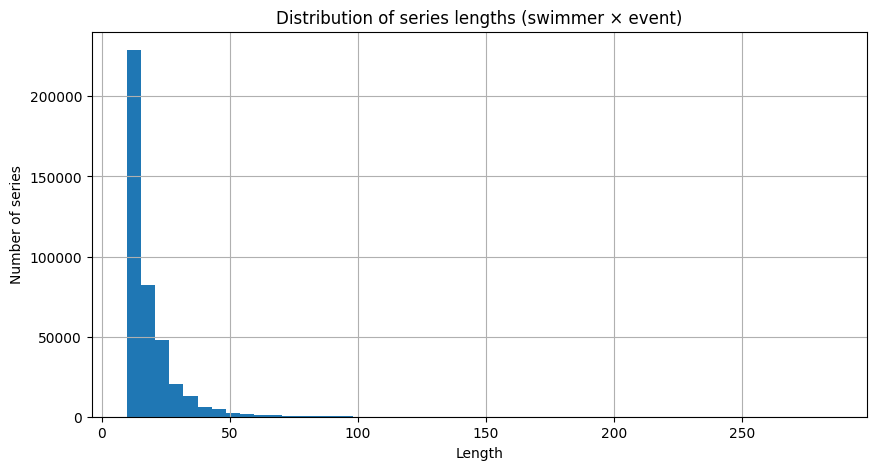

count    411445.000000
mean         17.807435
std          10.328437
min          10.000000
25%          12.000000
50%          15.000000
75%          20.000000
max         285.000000
Name: perf_date, dtype: float64


In [32]:
# Length distribution
series_lengths = data.groupby("series_id")["perf_date"].count()

plt.figure(figsize=(10,5))
series_lengths.hist(bins=50)
plt.title("Distribution of series lengths (swimmer × event)")
plt.xlabel("Length")
plt.ylabel("Number of series")
plt.show()

print(series_lengths.describe())

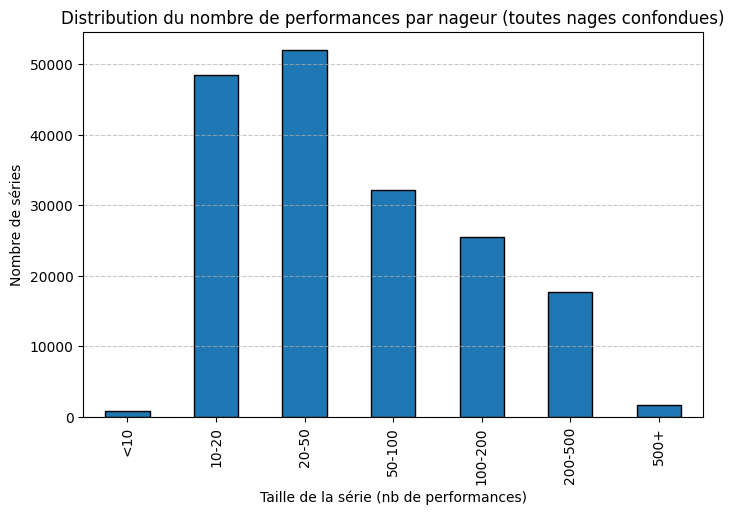

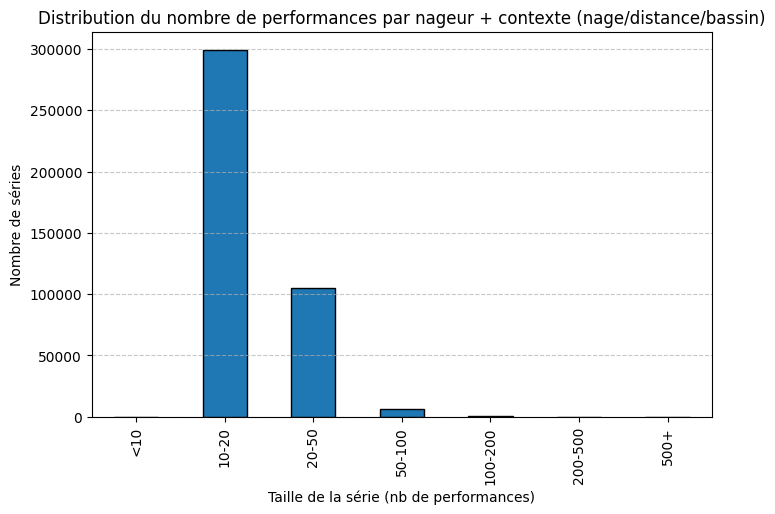


Résumé des séries :

        Type de série  Nombre total de séries  Longueur moyenne  Médiane
           Par nageur                  178465         80.988087     39.0
Par nageur + contexte                  411445         17.807435     15.0


In [33]:
series_lengths_context = data.groupby(group_keys)["perf_date"].count()

def plot_distribution(series_lengths, title):
    bins = [0, 10, 20, 50, 100, 200, 500, 1000]
    labels = ["<10", "10-20", "20-50", "50-100", "100-200", "200-500", "500+"]
    series_bins = pd.cut(series_lengths, bins=bins, labels=labels, right=False)
    dist = series_bins.value_counts().sort_index()

    plt.figure(figsize=(8,5))
    dist.plot(kind="bar", edgecolor="black")
    plt.title(title)
    plt.xlabel("Taille de la série (nb de performances)")
    plt.ylabel("Nombre de séries")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

plot_distribution(series_lengths_nageur, "Distribution du nombre de performances par nageur (toutes nages confondues)")

plot_distribution(series_lengths_context, "Distribution du nombre de performances par nageur + contexte (nage/distance/bassin)")

summary = pd.DataFrame({
    "Type de série": ["Par nageur", "Par nageur + contexte"],
    "Nombre total de séries": [len(series_lengths_nageur), len(series_lengths_context)],
    "Longueur moyenne": [series_lengths_nageur.mean(), series_lengths_context.mean()],
    "Médiane": [series_lengths_nageur.median(), series_lengths_context.median()]
})

print("\nRésumé des séries :\n")
print(summary.to_string(index=False))

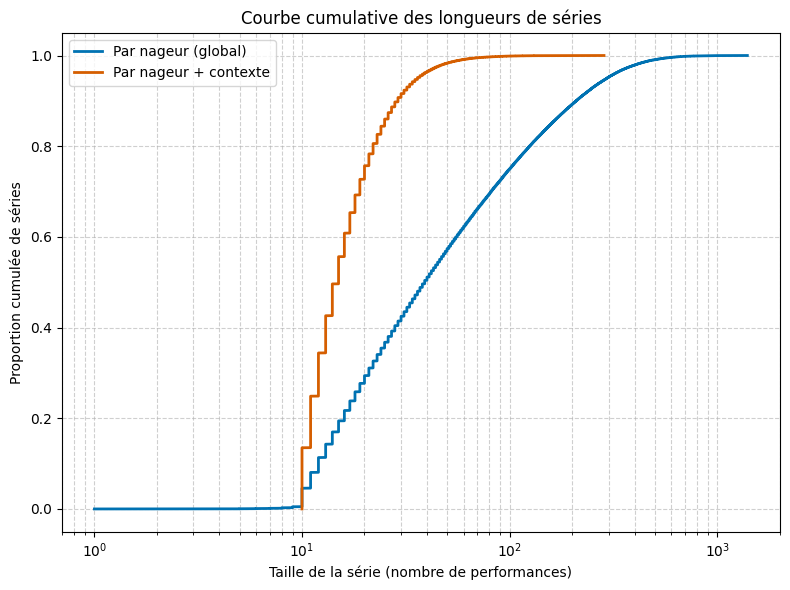

In [34]:

def plot_cumulative(series_lengths, label, color):
    sorted_lengths = np.sort(series_lengths.values)
    cum_ratio = np.arange(1, len(sorted_lengths)+1) / len(sorted_lengths)
    plt.plot(sorted_lengths, cum_ratio, label=label, color=color, linewidth=2)

plt.figure(figsize=(8,6))

plot_cumulative(series_lengths_nageur, "Par nageur (global)", "#0072B2")
plot_cumulative(series_lengths_context, "Par nageur + contexte", "#D55E00")

plt.xscale("log")
plt.xlabel("Taille de la série (nombre de performances)")
plt.ylabel("Proportion cumulée de séries")
plt.title("Courbe cumulative des longueurs de séries")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Avec ces graphiques, on remarque que le nombre de série exploitable est très bas avec un nombre de série médian égale à 3, si on considère une série comme étant un nageur sur une sous discipline précise dans le temps (50m nage libre par exemple). Cependant si on considère une série comme un nageur et toutes ses performances confondue dans le temps, on arrive à un nombre de série médian égale à 39.

Le contexte de nage sera donc considéré par le modèle grâce au features associés à chaque pas de temps de la série (i.e. à chaque performance).

Une bonne architecture moderne pour ce genre de problème pourrait être soit un LSTM, ou alors pour faire encore plus tendance un modèle Transformers.

Pour les Transformers on peut s'inspirer de [**Temporal Fusion Transformer (TFT) de Lim et al. (2021)**](https://arxiv.org/abs/1912.09363).

In [35]:
import json
import pickle
import os

SAVE_DIR = "../models"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Sauvegarde label encoders  ---
with open(os.path.join(SAVE_DIR, "encoder_perf_nage.pkl"), "wb") as f:
    pickle.dump(le, f)

with open(os.path.join(SAVE_DIR, "encoder_sexe.pkl"), "wb") as f:
    pickle.dump(le_sexe, f)

with open(os.path.join(SAVE_DIR, "encoder_perf_distance.pkl"), "wb") as f:
    pickle.dump(le_distance, f)

with open(os.path.join(SAVE_DIR, "encoder_perf_bassin.pkl"), "wb") as f:
    pickle.dump(le_bassin, f)

# --- Sauvegarde scaler pour age ---
with open(os.path.join(SAVE_DIR, "scaler_age.pkl"), "wb") as f:
    pickle.dump(scaler, f)

print("Encoders & scalers saved successfully!")


Encoders & scalers saved successfully!


In [36]:
data.to_csv("../data/performances_cleaned.csv", index=False)

## Mise en évidence du lien temporel

Explication des méthodes et métriques utilisées [ici](https://www.kaggle.com/code/iamleonie/time-series-interpreting-acf-and-pacf). 

In [35]:
# ==========================
# Time-series evidence by series_id
# ==========================

# Parameters
N_SWIMMERS = 10000
MAX_SERIES_LENGTH = None

eligible_swimmers = data['nageur_id'].unique()
np.random.seed(42)
sampled = np.random.choice(eligible_swimmers, size=min(N_SWIMMERS, len(eligible_swimmers)), replace=False)

data_sub = data[data['nageur_id'].isin(sampled)].copy()

# Sort properly for time series
data_sub = data_sub.sort_values(["series_id","perf_date"])

# Optional truncation of long series
if MAX_SERIES_LENGTH:
    data_sub = (data_sub.groupby("series_id")
                          .apply(lambda g: g.tail(MAX_SERIES_LENGTH))
                          .reset_index(drop=True))

print(f"Subset rows: {len(data_sub)},  unique series: {data_sub['series_id'].nunique()}")


Subset rows: 1045622,  unique series: 58875


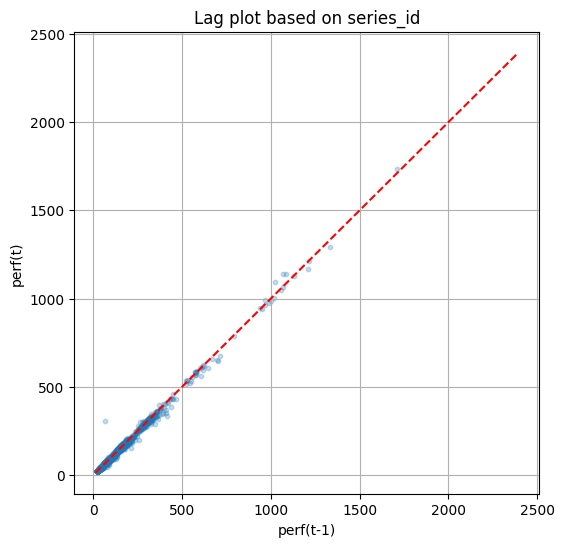

In [37]:
# ============= Lag Plot =============

pairs = []

for sid, g in data_sub.groupby("series_id"):
    y = g['perf_temps_sec'].values
    if len(y) > 1:
        pairs.append(np.column_stack((y[:-1], y[1:])))

pairs = np.vstack(pairs)

# random sample for visualization
idx = np.random.choice(len(pairs), size=min(5000, len(pairs)), replace=False)
sample_pairs = pairs[idx]

plt.figure(figsize=(6,6))
plt.scatter(sample_pairs[:,0], sample_pairs[:,1], alpha=0.25, s=10)
plt.xlabel("perf(t-1)")
plt.ylabel("perf(t)")
plt.title("Lag plot based on series_id")
lims = [min(pairs.min(),pairs.min()), max(pairs.max(),pairs.max())]
plt.plot(lims, lims, 'r--')
plt.grid()
plt.show()


Used series: 58875  | desired lag: 10
Shape ACF: (58875, 11) PACF: (58875, 11)


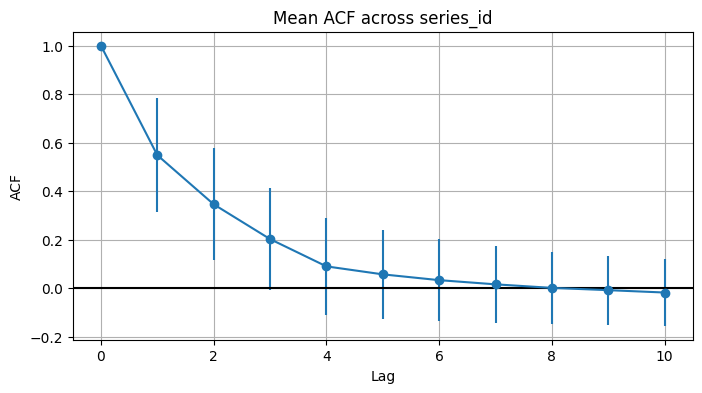

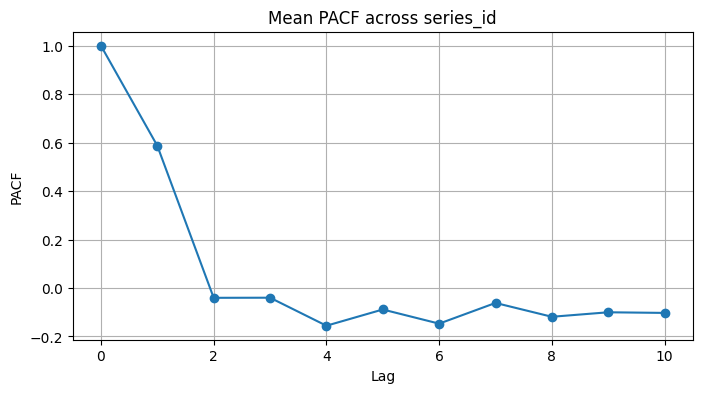

In [40]:
# ================= Robust ACF/PACF computation per series =================

from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings("ignore")  # hide PACF spam

max_lag = 10  # desired visual lag
acfs, pacfs_list = [], []

for sid, g in data_sub.groupby("series_id"):
    y = g["perf_temps_sec"].values
    n = len(y)

    if n < 5: 
        continue

    # Allowed maximum lag given sample length
    allowed_lag = min(max_lag, (n//2)-1)

    if allowed_lag < 1:
        continue

    y = y - np.mean(y)

    try:
        a = acf(y, nlags=allowed_lag, fft=True)
        p = pacf(y, nlags=allowed_lag, method="ld")   # Levinson-Durbin = stable PACF

        # Pad to fixed length for plotting
        a = np.pad(a, (0, max_lag+1-len(a)), mode='constant', constant_values=np.nan)
        p = np.pad(p, (0, max_lag+1-len(p)), mode='constant', constant_values=np.nan)

        acfs.append(a)
        pacfs_list.append(p)

    except Exception as e:
        continue

acfs = np.array(acfs)
pacfs = np.array(pacfs_list)

print("Used series:", len(acfs), " | desired lag:", max_lag)
print("Shape ACF:", acfs.shape, "PACF:", pacfs.shape)

mean_acf = np.nanmean(acfs, axis=0)
std_acf  = np.nanstd(acfs , axis=0)

# ---- Plot ACF ----
plt.figure(figsize=(8,4))
plt.errorbar(range(max_lag+1), mean_acf, yerr=std_acf, fmt='o-')
plt.axhline(0, color='k'); plt.grid()
plt.title("Mean ACF across series_id")
plt.xlabel("Lag"); plt.ylabel("ACF")
plt.show()

# ---- Plot PACF ----
plt.figure(figsize=(8,4))
plt.plot(range(max_lag+1), np.nanmean(pacfs, axis=0), 'o-')
plt.grid()
plt.title("Mean PACF across series_id")
plt.xlabel("Lag"); plt.ylabel("PACF")
plt.show()


Series tested: 58875
Series with significant autocorrelation: 29496/58875 = 0.50


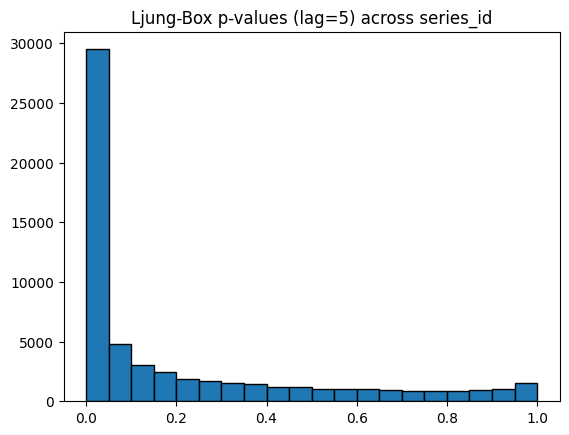

In [41]:
# ============= Ljung-Box test =============

from statsmodels.stats.diagnostic import acorr_ljungbox

alpha = 0.05
tested = 0
significant = 0
pvals=[]

for sid, g in data_sub.groupby("series_id"):
    y = g['perf_temps_sec'].values
    if len(y) < 10:
        continue

    y = y - y.mean()
    lb = acorr_ljungbox(y, lags=[5], return_df=True)
    p = lb['lb_pvalue'].iloc[0]
    tested += 1
    pvals.append(p)
    if p < alpha:
        significant += 1

print(f"Series tested: {tested}")
print(f"Series with significant autocorrelation: {significant}/{tested} = {significant/tested:.2f}")

plt.hist(pvals, bins=20, edgecolor='black')
plt.title("Ljung-Box p-values (lag=5) across series_id")
plt.show()
